<a href="https://colab.research.google.com/github/SAMAD-KHAN03/ml/blob/master/algorithms/Unsupervised/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

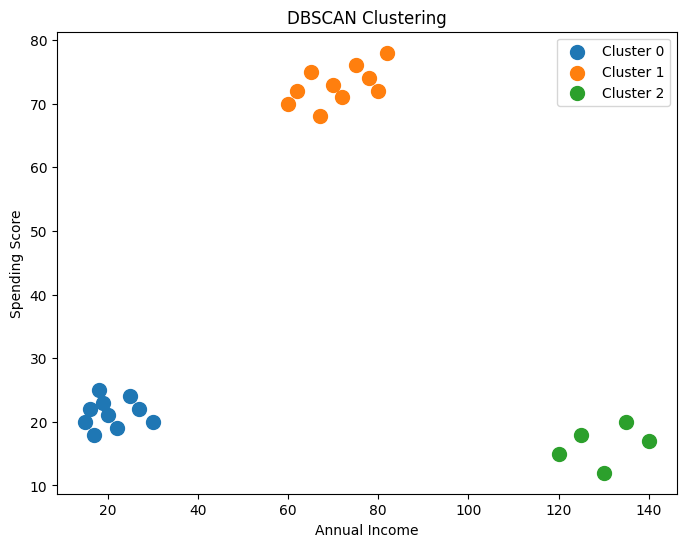

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Sample Customer Data
data = {
    'Annual_Income': [15,16,17,18,19,20,22,25,27,30,
                      60,62,65,67,70,72,75,78,80,82,
                      120,125,130,135,140],
    'Spending_Score': [20,22,18,25,23,21,19,24,22,20,
                       70,72,75,68,73,71,76,74,72,78,
                       15,18,12,20,17]
}

df = pd.DataFrame(data)

# Features
X = df[['Annual_Income', 'Spending_Score']]

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN Model
dbscan = DBSCAN(
    eps=0.6,        # neighborhood radius
    min_samples=3   # minimum points to form cluster
)

clusters = dbscan.fit_predict(X_scaled)

# Visualization
plt.figure(figsize=(8,6))

unique_clusters = np.unique(clusters)

for cluster in unique_clusters:
    mask = clusters == cluster

    if cluster == -1:
        plt.scatter(
            df[mask]['Annual_Income'],
            df[mask]['Spending_Score'],
            s=150,
            marker='x',
            label='Noise'
        )
    else:
        plt.scatter(
            df[mask]['Annual_Income'],
            df[mask]['Spending_Score'],
            s=100,
            label=f'Cluster {cluster}'
        )

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('DBSCAN Clustering')
plt.legend()
plt.show()